In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/genz_mental_wellness_synthetic_dataset.csv")

In [3]:
persona_features = [
    "Daily_Social_Media_Hours",
    "Screen_Time_Hours",
    "Night_Scrolling_Frequency",
    "Online_Gaming_Hours",
    "Exercise_Frequency_per_Week",
    "Daily_Sleep_Hours",
    "Study_Work_Hours_per_Day",
    "Anxiety_Score",
    "Motivation_Level"
]

In [4]:
from sklearn.preprocessing import StandardScaler

In [5]:
X = df[persona_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

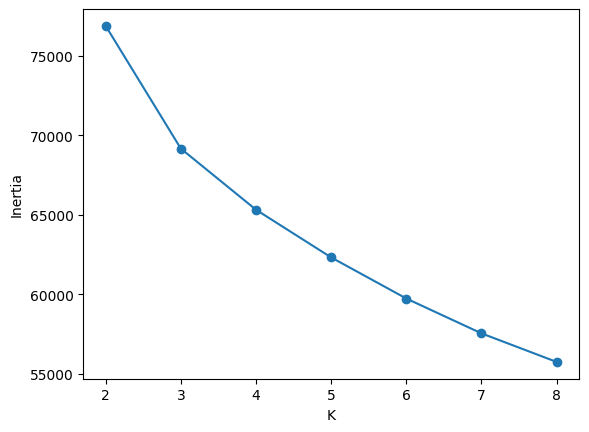

In [7]:
inertia = []
for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)
plt.plot(range(2,9), inertia, marker="o")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

In [8]:
from sklearn.metrics import silhouette_score

In [9]:
for k in range(2,9):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    print(k, score)

2 0.1330569727169777
3 0.11951260852193923
4 0.09811651762752653
5 0.09707843385408357
6 0.09544426609420274
7 0.09385554946412597
8 0.09263623455253928


In [10]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Persona"] = kmeans.fit_predict(X_scaled)

persona_summary = (
    df.groupby("Persona")[persona_features]
      .mean()
)

print(persona_summary)

         Daily_Social_Media_Hours  Screen_Time_Hours  \
Persona                                                
0                        2.933260           5.711541   
1                        2.920760           5.704688   
2                        5.192426           8.442784   
3                        5.107505           8.364978   

         Night_Scrolling_Frequency  Online_Gaming_Hours  \
Persona                                                   
0                         3.162283             1.637414   
1                         2.737233             1.670537   
2                         3.317159             1.672479   
3                         2.745134             1.475423   

         Exercise_Frequency_per_Week  Daily_Sleep_Hours  \
Persona                                                   
0                           2.670129           5.922154   
1                           3.384989           7.465899   
2                           2.645081           5.635882   
3            

In [11]:
persona_map = {
    0: "Stressed Minimalist",
    1: "Balanced Achiever",
    2: "Burnout-Prone Doomscroller",
    3: "High-Engagement Optimizer"
}

In [12]:
df["Persona_Name"] = df["Persona"].map(persona_map)

In [13]:
import joblib

In [14]:
joblib.dump(
    kmeans,
    "../models/persona_model.pkl"
)

joblib.dump(
    scaler,
    "../models/persona_scaler.pkl"
)

joblib.dump(
    persona_map,
    "../models/persona_names.pkl"
)

['../models/persona_names.pkl']

In [15]:
import os

print(os.path.exists("../models/persona_model.pkl"))
print(os.path.exists("../models/persona_scaler.pkl"))
print(os.path.exists("../models/persona_names.pkl"))

True
True
True
